# SeriesGAN
@misc{eskandarinasab2024seriesgan,<br>
&nbsp;&nbsp;title={SeriesGAN: Time Series Generation via Adversarial and Autoregressive Learning},<br>
&nbsp;&nbsp;author={MohammadReza EskandariNasab and Shah Muhammad Hamdi and Soukaina Filali Boubrahimi},<br>
&nbsp;&nbsp;year={2024},<br>
&nbsp;&nbsp;eprint={2410.21203},<br>
&nbsp;&nbsp;archivePrefix={arXiv},<br>
&nbsp;&nbsp;primaryClass={cs.LG},<br>
&nbsp;&nbsp;url={https://arxiv.org/abs/2410.21203},<br>
}

In [ ]:
## Necessary packages
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
tf.compat.v1.disable_eager_execution()
import logging
tf.get_logger().setLevel(logging.ERROR)

# 1. SeriesGan model
from seriesgan import seriesgan

# 3. Metrics
from metrics.discriminative_metrics import discriminative_score_metrics
from metrics.predictive_metrics import predictive_score_metrics
from metrics.visualization_metrics import visualization

# Data Loading
Load original dataset and preprocess the loaded data.

In [ ]:
# Load data
def load_data():
    real_vectors = np.load("/Users/angzeng/GitHub/wisepanda/algorithm/dataset/Bamboo500.npy")
    # Normalize data to [-1, 1] range to match generator output
    data = torch.tensor(real_vectors, dtype=torch.float32)
    data = (data - data.min()) / (data.max() - data.min()) * 2 - 1
    return data

In [336]:
original_data = load_data().unsqueeze(-1).numpy()
generated_data = []

SeriesGAN network parameters should be optimized for different datasets.

hidden_dim: hidden dimensions -> input 'same' or a number such as 8
num_layer: number of layers
iteration: number of training iterations
batch_size: the number of samples in each batch

In [337]:
## Newtork parameters
parameters = dict()

parameters['hidden_dim'] = 'same'
parameters['iterations'] = 6 * 1000
parameters['batch_size'] = 128
parameters['num_layer'] = 4


In [338]:
seriesgan_result = seriesgan(original_data, parameters, 7000)

Start Autoencoder Training for Loss
step: 0/6000, AE_loss: 0.0504
step: 1000/6000, AE_loss: 0.0096
step: 2000/6000, AE_loss: 0.0128
step: 3000/6000, AE_loss: 0.0121
step: 4000/6000, AE_loss: 0.0173
step: 5000/6000, AE_loss: 0.0111
step: 5998/6000, AE_loss: 0.0161
Finish Autoencoder Training for Loss
Start Embedding Network Training
step: 0/6000, AE_loss: 0.26, AE_D_loss: 0.9974
step: 1000/6000, AE_loss: 0.0526, AE_D_loss: 0.5003
step: 2000/6000, AE_loss: 0.0192, AE_D_loss: 0.5001
step: 3000/6000, AE_loss: 0.0212, AE_D_loss: 0.5
step: 4000/6000, AE_loss: 0.0167, AE_D_loss: 0.5
step: 5000/6000, AE_loss: 0.0166, AE_D_loss: 0.5
step: 5998/6000, AE_loss: 0.0174, AE_D_loss: 0.5
Finish Embedding Network Training
Start Training with Supervised Loss Only
step: 0/6000, S_loss: 0.1616
step: 1000/6000, S_loss: 0.0024
step: 2000/6000, S_loss: 0.003
step: 3000/6000, S_loss: 0.002
step: 4000/6000, S_loss: 0.0017
step: 5000/6000, S_loss: 0.0009
step: 5999/6000, S_loss: 0.0005
Finish Training with Supe

In [339]:
generated_seriesgan_result = seriesgan_result[:6000].reshape(-1, 64)
np.save('generated_vectors_seriesgan_new.npy', generated_seriesgan_result)

# Erosion process
erosion process  

In [340]:
class FractureCurveGenerator:
    def __init__(self, count_fiber, K_Ⅲ, len_x, ce_rate, erosion_epoch, data_file="generated_vectors.npy", save_path='seriesgan_data_6000.npy'):
        self.count_fiber = count_fiber
        self.K_Ⅲ = K_Ⅲ
        self.len_x = len_x
        self.ce_rate = ce_rate
        self.erosion_epoch = erosion_epoch
        self.save_path = save_path
        self.data_file = data_file
        
        # Load pre-generated data
        self.generated_samples = np.load(data_file)
        self.current_index = 0  # Track current data index being used
        
        print(f"Loaded {len(self.generated_samples)} samples from {data_file}")
        print(f"Sample shape: {self.generated_samples.shape}")

    def create_fiber_line(self): 
        '''Description: This function is used to generate the fracture curve'''
        # Get a sample from pre-loaded data
        if self.current_index >= len(self.generated_samples):
            # If all data is used up, start over with cycling
            self.current_index = 0
            print("Warning: Reusing data samples as all samples have been used.")
        
        # Get current sample
        sample = self.generated_samples[self.current_index]
        self.current_index += 1
        
        # Convert to list format
        if isinstance(sample, np.ndarray):
            y_list = sample.tolist()
        else:
            y_list = [sample] if not isinstance(sample, list) else sample
            
        return y_list

    def reset_data_index(self):
        '''Reset the data index to start from the beginning'''
        self.current_index = 0

    def get_random_fiber_line(self):
        '''Get a random sample from the loaded data'''
        random_index = np.random.randint(0, len(self.generated_samples))
        sample = self.generated_samples[random_index]
        
        if isinstance(sample, np.ndarray):
            y_list = sample.tolist()
        else:
            y_list = [sample] if not isinstance(sample, list) else sample
            
        return y_list

    def relu(self, x):
        '''Calculate the ReLU activation function'''
        return np.maximum(0, x)

    def erosion_new(self, list):
        '''Generate a single step of erosion on the curve'''
        new_list = []
        for i in range(len(list)):
            # Determine left and right neighbor values
            if i == 0:
                left_fiber = list[i]
                if len(list) == 1:
                    right_fiber = list[i]
                else:
                    right_fiber = list[i+1]
            elif i == len(list)-1:
                left_fiber = list[i-1]
                right_fiber = list[i]
            else:
                left_fiber = list[i-1]
                right_fiber = list[i+1]
            
            # Calculate erosion for each fiber element
            structural_area = self.relu(list[i]-left_fiber)+self.relu(list[i]-right_fiber)  # Calculate structural area
            erosion_fiber = list[i]-structural_area*self.ce_rate
            new_list.append(erosion_fiber)

        return new_list

    def erosion_with_epoch(self, list, epoch): 
        '''Apply erosion process for multiple epochs'''
        for i in range(epoch):
            list = self.erosion_new(list)
        return list

    def floor_list(self, list, floor):
        '''Adjust the list values to a specified floor level'''
        min_value = min(list) + floor
        adjusted_list = [x - min_value for x in list]
        return adjusted_list

    def revers_list(self, list, floor): 
        '''Reverse the list values and adjust to floor level'''
        inverted_list = [-x for x in list]
        return self.floor_list(inverted_list, floor)

    def get_top_erosion_fiber(self, list, epoch, floor): 
        '''Generate the top erosion fiber through reverse processing'''
        reversed_list = self.revers_list(list, 0)
        erosioned_list = self.erosion_with_epoch(reversed_list, epoch)
        adjusted_list = self.revers_list(erosioned_list, -floor)
        return adjusted_list

    def fibers_resize(self, list, num):
        '''Resize fibers to specified number of points using interpolation'''
        # Create new indices with specified length
        new_indices = np.linspace(0, len(list) - 1, num=num)
        # Use linear interpolation
        resampled_list = np.interp(new_indices, np.arange(len(list)), list)
        resampled_list = [64*x/self.count_fiber for x in resampled_list]
        resampled_list = [round(x, 4) for x in resampled_list]
        return resampled_list

    def get_pair_fibers(self, use_random=False):
        '''Generate a pair of erosion fibers (top and bottom)'''
        if use_random:
            fracture_list = self.get_random_fiber_line()
        else:
            fracture_list = self.create_fiber_line()
            
        erosion_list = self.erosion_with_epoch(fracture_list, self.erosion_epoch)
        erosion_list = self.floor_list(erosion_list, 0)
        top_erosion_list = self.get_top_erosion_fiber(fracture_list, self.erosion_epoch, 0)
        return self.fibers_resize(erosion_list, 64), self.fibers_resize(top_erosion_list, 64)

    def get_fracture_curves(self, data_amount):
        '''Generate processed fracture curve data for training'''
        data_list = []
        array_zero = np.zeros(64)
        
        # Reset index to start from the beginning
        self.reset_data_index()
        
        # Generate basic fracture curve pairs
        for i in range(data_amount):
            a, b = self.get_pair_fibers()
            vector_edge_top = np.array(a)
            vector_edge_bottom = np.array(b)
            list_top_bottom = [array_zero, array_zero, vector_edge_top, vector_edge_bottom]
            data_list.append(list_top_bottom)

        all_data_list = np.array(data_list)
        np.save(self.save_path, all_data_list)
        print(f"Saved {len(all_data_list)} processed samples to '{self.save_path}'")
        return all_data_list

In [346]:
generator = FractureCurveGenerator(
    count_fiber=64,  # 根据generated_vectors.npy的数据维度设置
    K_Ⅲ=1.0,
    len_x=3,
    ce_rate=0.02,
    erosion_epoch=500,
    data_file="generated_vectors_seriesgan.npy",
    save_path="generated_vectors_seriesgan_0.02_6000.npy"
)

processed_data = generator.get_fracture_curves(6000)

Loaded 6000 samples from generated_vectors_seriesgan.npy
Sample shape: (6000, 64)
Saved 6000 processed samples to 'generated_vectors_seriesgan_0.02_6000.npy'


In [347]:
generator = FractureCurveGenerator(
    count_fiber=64,  # 根据generated_vectors.npy的数据维度设置
    K_Ⅲ=1.0,
    len_x=3,
    ce_rate=0.01,
    erosion_epoch=500,
    data_file="generated_vectors_seriesgan.npy",
    save_path="generated_vectors_seriesgan_0.01_6000.npy"
)

processed_data = generator.get_fracture_curves(6000)

Loaded 6000 samples from generated_vectors_seriesgan.npy
Sample shape: (6000, 64)
Saved 6000 processed samples to 'generated_vectors_seriesgan_0.01_6000.npy'


# Perturbation process
prosion process

In [539]:
def perturb_curve(y, noise_level=0.02):
    """
    Simplified curve perturbation function to add realistic roughness
    
    Args:
        y: Original curve data (1D numpy array, float32 format)
        noise_level: Overall noise strength (0.01-0.1 recommended)
    
    Returns:
        Perturbed curve with added roughness (same format as input)
    """
    # Ensure input is numpy array and preserve original dtype
    y = np.asarray(y)
    original_dtype = y.dtype
    
    x = np.linspace(0, 1, len(y))
    
    # 1. Basic Gaussian noise
    basic_noise = np.random.normal(0, noise_level, len(y))
    
    # 2. High-frequency noise for fine-scale variations
    high_freq = np.random.normal(0, noise_level * 0.5, len(y))
    high_freq = 0
    
    # 3. Mid-frequency periodic perturbation
    mid_freq = np.sin(2*np.pi*5*x) * noise_level * 2
    
    # 4. Low-frequency drift for long-term variations
    low_freq = np.cumsum(np.random.normal(0, noise_level/10, len(y)))
    low_freq = low_freq - np.linspace(low_freq[0], low_freq[-1], len(low_freq))
    
    # 5. Nonlinear perturbation: y_new = y + β * sin(γ * y) * noise
    nonlinear_noise = np.random.normal(0, noise_level * 0.8, len(y))
    nonlinear = 0.03 * np.sin(2 * y) * nonlinear_noise
    
    # Combine all perturbations
    y_perturbed = y + basic_noise + high_freq + mid_freq + low_freq + nonlinear
    
    # Preserve original dtype (float32)
    return y_perturbed.astype(original_dtype)

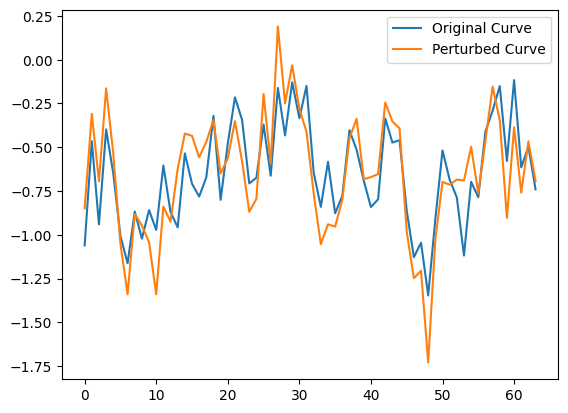

In [551]:
samples = np.load("generated_vectors_seriesgan.npy")
samples_perturbed = perturb_curve(samples[2], noise_level=0.12)
plt.plot(samples[2], label='Original Curve')
plt.plot(samples_perturbed, label='Perturbed Curve')
plt.legend()
plt.show()

In [548]:
generated_samples = np.load("generated_vectors_seriesgan.npy")
perturbed_samples = [perturb_curve(sample, noise_level=0.12) for sample in generated_samples]
np.save("generated_vectors_seriesgan_perturbed.npy", perturbed_samples)

In [454]:
generator = FractureCurveGenerator(
    count_fiber=64,  
    K_Ⅲ=1.0,
    len_x=3,
    ce_rate=0.02,
    erosion_epoch=500,
    data_file="generated_vectors_seriesgan_perturbed.npy",
    save_path="generated_vectors_seriesgan_perturbed_0.02_6000.npy"
)

processed_data = generator.get_fracture_curves(6000)

Loaded 6000 samples from generated_vectors_seriesgan_perturbed.npy
Sample shape: (6000, 64)
Saved 6000 processed samples to 'generated_vectors_seriesgan_perturbed_0.02_6000.npy'


In [110]:
#WisePanda
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/dataset/vector_reallike_6000_0826.npy')
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/dataset/vector_reallike_6000_0903.npy')


# real
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/dataset/vector_real_118_patch.npy')

#GAN
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/GANs/GAN/generated_vectors_GAN_0.01_6000.npy')
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/GANs/GAN/generated_vectors_GAN_0.02_6000.npy')
generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/GANs/GAN/generated_vectors_GAN_0.02_6000(1350).npy')



generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/GANs/GAN/generated_vectors_GAN(236).npy')


#seriesGan
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/GANs/SeriesGAN/generated_vectors_seriesgan_0.01_6000.npy')
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/GANs/SeriesGAN/generated_vectors_seriesgan_0.02_6000.npy')

#diffusion
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/Diffusion/Diffusion_1d/generated_vectors_diffusion_0.01_6000.npy')
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/Diffusion/Diffusion_1d/generated_vectors_diffusion_0.02_6000.npy')

# diffusion-TS
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/Diffusion/Diffusion-TS/generated_vectors_diffusion-TS_0.01_6000.npy')
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/Diffusion/Diffusion-TS/generated_vectors_diffusion-TS_0.02_6000.npy')


# perturbed

#GAN
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/GANs/GAN/generated_vectors_GAN_perturbed_0.02_6000.npy')

#seriesGan
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/GANs/SeriesGAN/generated_vectors_seriesgan_perturbed_0.02_6000.npy')

#diffusion
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/Diffusion/Diffusion_1d/generated_vectors_diffusion_perturbed_0.02_6000.npy')

# diffusion-TS
#generated_samples = np.load('/Users/angzeng/GitHub/wisepanda/algorithm/extend_compare/Diffusion/Diffusion-TS/generated_vectors_diffusion-TS_perturbed_0.02_6000.npy')


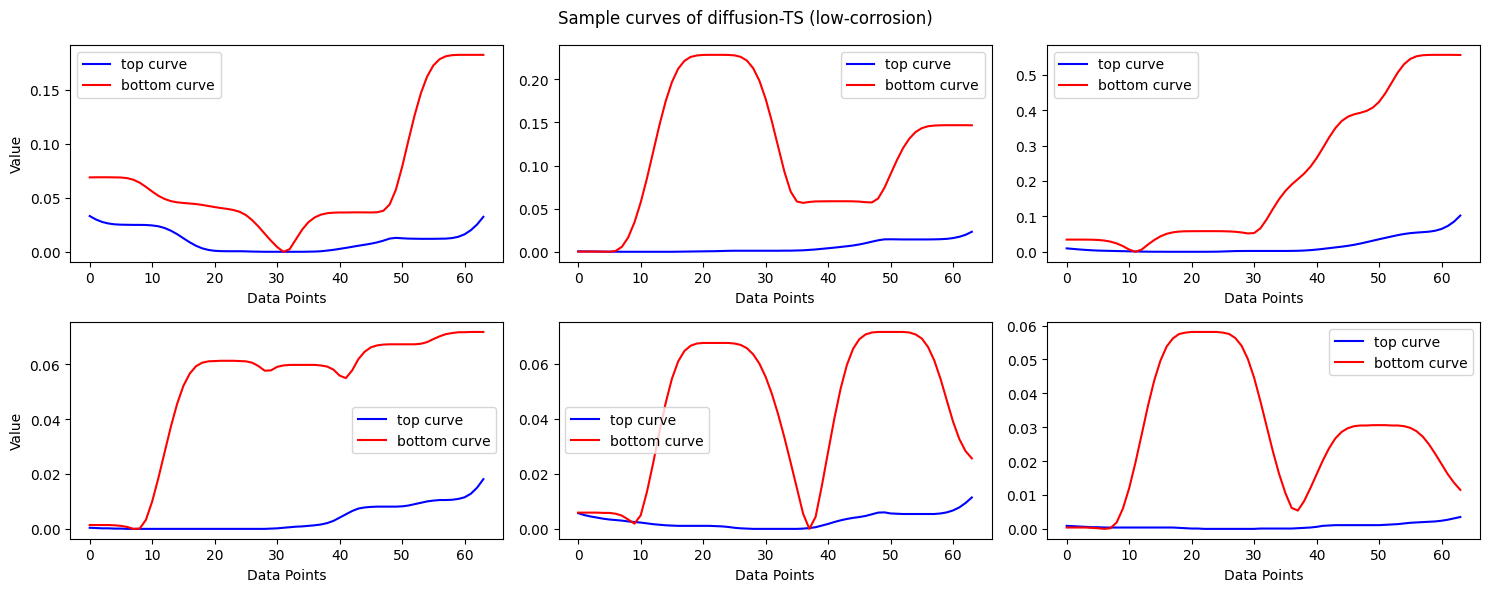

In [108]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
#fig.suptitle('Sample curves of diffusion-TS', fontsize=12)
fig.suptitle('Sample curves of diffusion-TS (low-corrosion)', fontsize=12)


random_integers_np_array = np.random.randint(0, 118, size=6)

# 将NumPy数组转换为标准的Python列表
random_list = random_integers_np_array.tolist()

axes_flat = axes.flatten()
i_values = [106,5,10,30,60,100]
#i_values = [1,2,3,4,5,100]
i_values = random_list
for idx, i in enumerate(i_values):
    ax = axes_flat[idx]
    ax.plot(generated_samples[i][2], label='top curve', color='blue')
    ax.plot(generated_samples[i][3], label='bottom curve', color='red')
    ax.legend()
    if idx % 3 == 0:
        ax.set_ylabel("Value")
    ax.set_xlabel("Data Points")

plt.tight_layout()

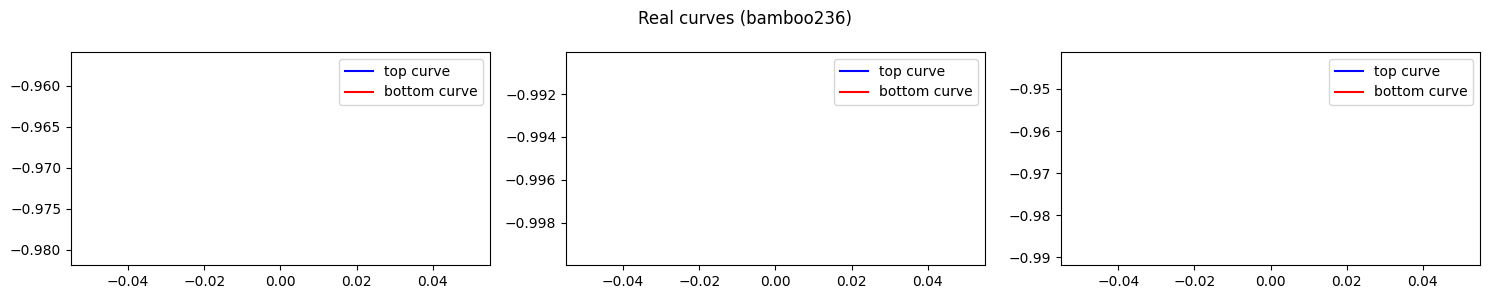

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
#fig.suptitle('Sample curves of diffusion-TS', fontsize=12)
fig.suptitle('Real curves (bamboo236)', fontsize=12)

i_values = [109,88,77]
for idx, i in enumerate(i_values):
    ax = axes[idx]
    ax.plot(generated_samples[i][2], label='top curve', color='blue')
    ax.plot(generated_samples[i][3], label='bottom curve', color='red')
    ax.legend()
  

plt.tight_layout()

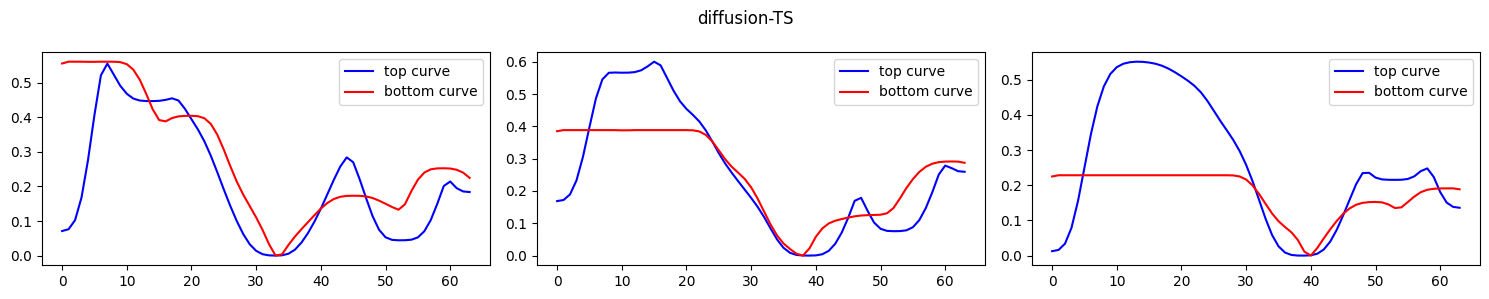

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
#fig.suptitle('Sample curves of diffusion-TS', fontsize=12)
fig.suptitle('diffusion-TS', fontsize=12)

i_values = [9,71,20]
for idx, i in enumerate(i_values):
    ax = axes[idx]
    ax.plot(generated_samples[i][2], label='top curve', color='blue')
    ax.plot(generated_samples[i][3], label='bottom curve', color='red')
    ax.legend()
  

plt.tight_layout()